In [1]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from utils import *
from genData import *
from plot import *
from model.unet import *

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. No GPU found.")

# Configuration
det = 'H1L1'
f0 = 20
size = (512, 64)
Tsft = 14400
train_level = 32
batch_size = 8

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)

25-08-28 17:18:23.164 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


CUDA is not available. No GPU found.


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [2]:
max_train_levels = [20]
duty_factor = 1.0 

# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets
    data = normalize(data)
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions, inputs, ground_truth = [], [], []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
            
    predictions = np.concatenate(predictions, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:05<00:00, 22.60it/s]


Input shape: (128, 64, 2)
Number of zero columns in data: 0
Number of NaN columns in dataset 0 (Noisy Signal Input): 0
Number of NaN columns in dataset 1 (Denoised Output): 0
Number of NaN columns in dataset 2 (Pure Signal): 0
vmin: 2.4920517038840018e-12, vmax: 0.9236642489426838


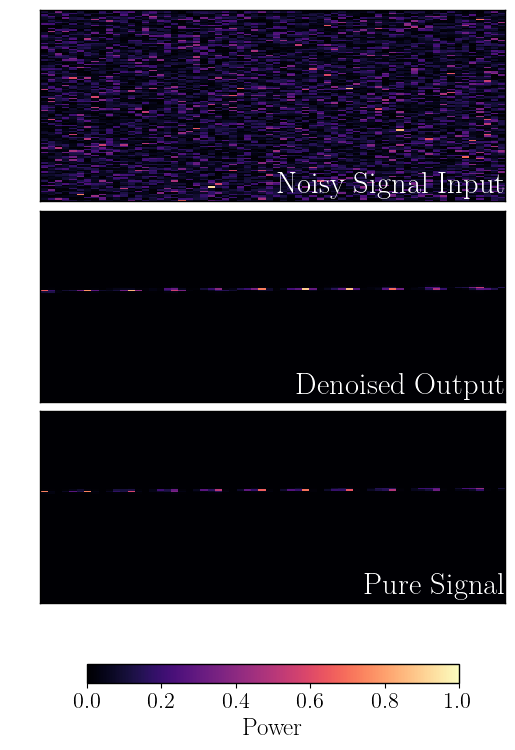

In [3]:
# Example usage
idx = 12
size = (512, 64)  # From your original code
Tsft = 14400  # From your original code
timestamps = np.arange(0, size[1]) * Tsft  # Uniform timestamps
frequency = np.arange(96, 256-32)  # Adjusted to match [96:256-32] slice
title = 'Spectrograms at 20 Hz'
subtitles = ['Noisy Signal Input', 'Denoised Output', 'Pure Signal']
fourier_data_list = [
    data[idx][96:256-32, :, :2],  # Shape: (160, 64, 2) selecting H1 real and imag
    predictions[idx].transpose(1, 2, 0)[96:256-32, :, :2],  # Adjusted to match data shape
    normalize(targets)[idx][96:256-32, :, :2]
]
fig, ax = plot_spectrograms(title, timestamps, frequency, fourier_data_list, subtitles)
#fig.savefig('../result/plots/20Hz_D20_spectrogram.pdf', dpi=300, bbox_inches='tight')

In [4]:
max_train_levels = [20]
duty_factor = 0.75
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets
    data = normalize(data)
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions = []
    inputs = []
    ground_truth = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
            
    predictions = np.concatenate(predictions, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:05<00:00, 23.51it/s]


Input shape: (128, 64, 2)
Number of zero columns in data: 16
Number of NaN columns in dataset 0 (Noisy Signal Input): 16
Number of NaN columns in dataset 1 (Denoised Output): 16
Number of NaN columns in dataset 2 (Pure Signal): 16
vmin: 7.417694930511587e-12, vmax: 0.7905353307723999


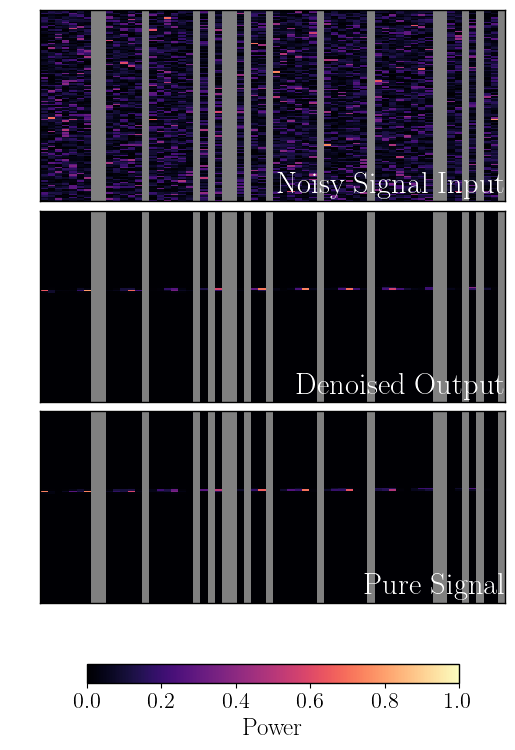

In [5]:
# Example usage
idx = 12
size = (512, 64)  # From your original code
Tsft = 14400  # From your original code
timestamps = np.arange(0, size[1]) * Tsft  # Uniform timestamps
frequency = np.arange(96, 256-32)  # Adjusted to match [96:256-32] slice
title = 'Spectrograms at 20 Hz'
subtitles = ['Noisy Signal Input', 'Denoised Output', 'Pure Signal']
fourier_data_list = [
    data[idx][96:256-32, :, :2],  # Shape: (160, 64, 2) selecting H1 real and imag
    predictions[idx].transpose(1, 2, 0)[96:256-32, :, :2],  # Adjusted to match data shape
    normalize(targets)[idx][96:256-32, :, :2]
]
fig, ax = plot_spectrograms(title, timestamps, frequency, fourier_data_list, subtitles)
#fig.savefig('../result/plots/20Hz_D20_spectrogram_gaps.pdf', dpi=300, bbox_inches='tight')

In [3]:
# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

f0 = 500
size = (512, 64)
Tsft = 14400
train_level = 22

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_seed4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))  # Assuming new_mask and normalize are defined in utils

# Load model
# model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
# best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
# model.load_state_dict(best_val_model)

In [60]:
def plot_spectrograms(timestamps, frequency, data):
    fig, axs = plt.subplots(1, 2, figsize=(16, 10))

    for ax in axs:
        ax.set(xlabel="SFT index", ylabel="Frequency [Hz]")

    time_in_days = (timestamps - timestamps[0]) / 1800

    axs[0].set_title("Signal")
    c = axs[0].pcolormesh(
        time_in_days,
        frequency,
        data[0],
        norm=colors.CenteredNorm(),
    )
    fig.colorbar(c, ax=axs[0], orientation="horizontal", label="Fourier Amplitude")

    axs[1].set_title("Mask")
    c = axs[1].pcolormesh(
        time_in_days,
        frequency,
        data[1],
        norm=colors.CenteredNorm(),
    )

    fig.colorbar(c, ax=axs[1], orientation="horizontal", label="Fourier Amplitude")

    return fig, axs

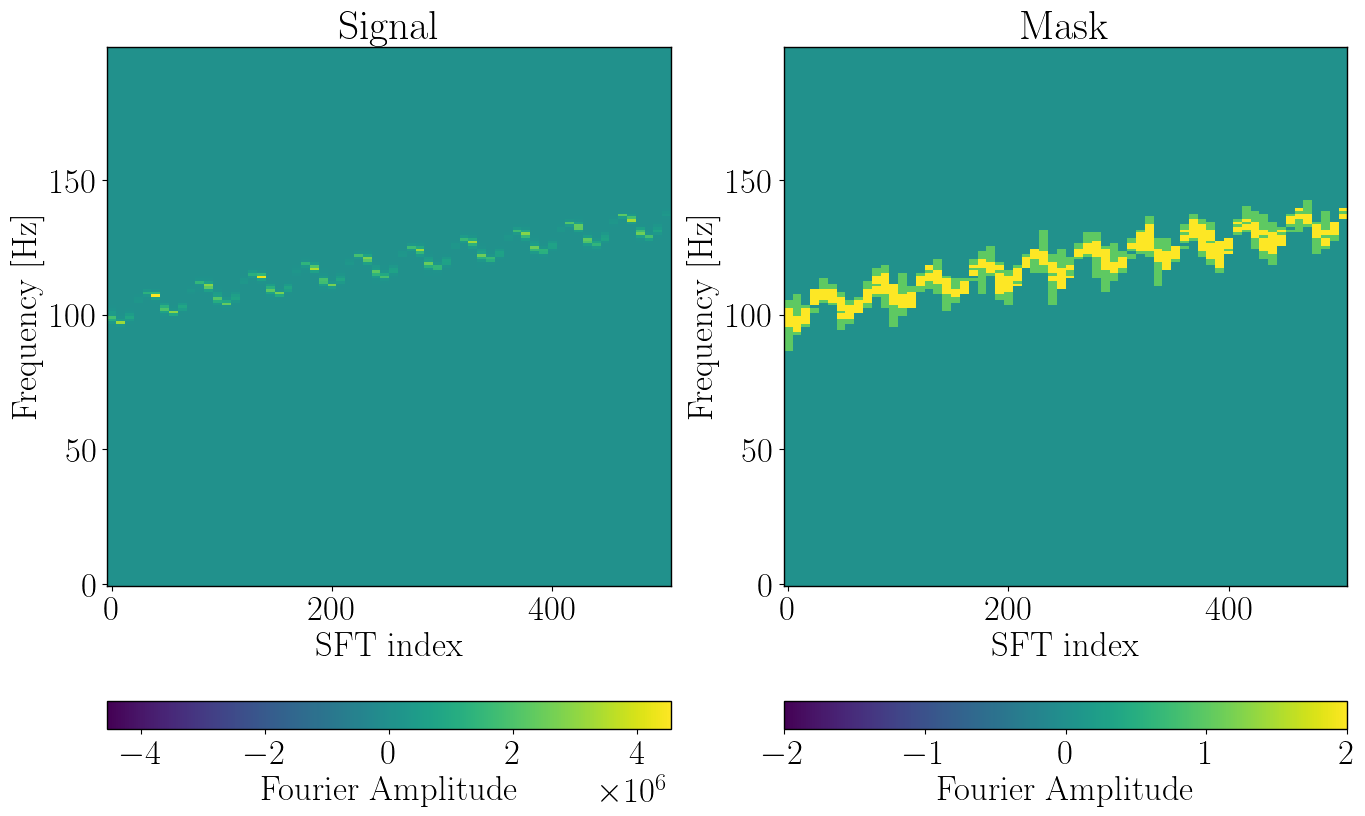

In [61]:
# Example usage
idx = 12
size = (512, 64)  # From your original code
Tsft = 14400  # From your original code
timestamps = np.arange(0, size[1]) * Tsft  # Uniform timestamps
frequency = np.arange(200)  # Adjusted to match [96:256-32] slice
title = 'Spectrograms at 500 Hz'
subtitles = ['Noisy Signal Input', 'Pure Signal']
fourier_data_list = [
    targets[idx][300:500, :, 0]**2+targets[idx][300:500, :, 1]**2,  # Shape: (160, 64, 2) selecting H1 real and imag
    masks[idx][300:500, :, 0]**2 + masks[idx][300:500, :, 1]**2
]
fig, ax = plot_spectrograms(timestamps, frequency, fourier_data_list)
fig.savefig('../result/plots/500Hz_mask_spectrogram.pdf', dpi=300, bbox_inches='tight')

In [7]:
max_train_levels = [20]
duty_factor = 1.0 

# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets
    data = normalize(data)
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions, inputs, ground_truth = [], [], []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
            
    predictions = np.concatenate(predictions, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:05<00:00, 24.01it/s]


Input shape: (200, 64, 2)
Number of zero columns in data: 0
Number of NaN columns in dataset 0 (Noisy Signal Input): 0
Number of NaN columns in dataset 1 (Denoised Output): 0
Number of NaN columns in dataset 2 (Pure Signal): 0
vmin: 1.863398671475558e-11, vmax: 1.1036732140937728


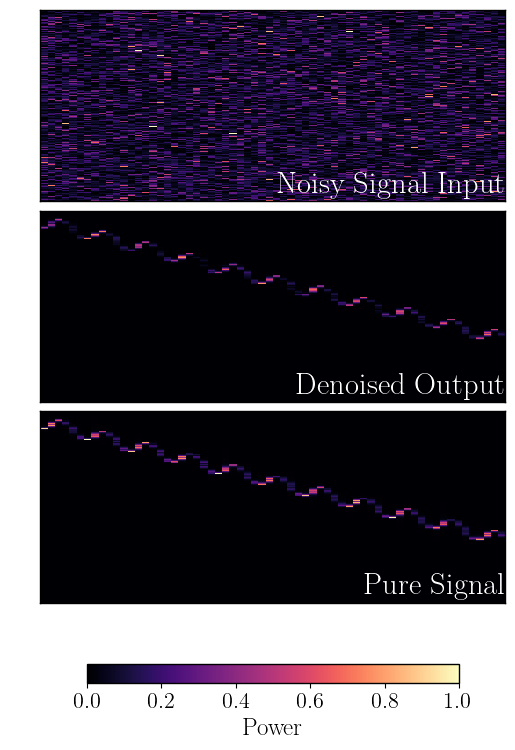

In [8]:
# Example usage
idx = 8
size = (512, 64)  # From your original code
Tsft = 14400  # From your original code
timestamps = np.arange(0, size[1]) * Tsft  # Uniform timestamps
frequency = np.arange(200)  # Adjusted to match [96:256-32] slice
title = 'Spectrograms at 500 Hz'
subtitles = ['Noisy Signal Input', 'Denoised Output', 'Pure Signal']
fourier_data_list = [
    data[idx][-300:-100, :, :2],  # Shape: (160, 64, 2) selecting H1 real and imag
    predictions[idx].transpose(1, 2, 0)[-300:-100, :, :2],  # Adjusted to match data shape
    normalize(targets)[idx][-300:-100, :, :2]
]
fig, ax = plot_spectrograms(title, timestamps, frequency, fourier_data_list, subtitles)
fig.savefig('../result/plots/500Hz_D20_spectrogram.pdf', dpi=300, bbox_inches='tight')

In [9]:
max_train_levels = [20]
duty_factor = 0.75
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    
    data = noise + targets
    data = normalize(data)
    data = apply_duty_factor(data, duty_factor, size)  # Apply duty factor
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)
    
    # Compute predictions
    predictions = []
    inputs = []
    ground_truth = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
            
    predictions = np.concatenate(predictions, axis=0)

Processing Sn=20: 100%|██████████| 125/125 [00:05<00:00, 24.03it/s]


Input shape: (200, 64, 2)
Number of zero columns in data: 16
Number of NaN columns in dataset 0 (Noisy Signal Input): 16
Number of NaN columns in dataset 1 (Denoised Output): 16
Number of NaN columns in dataset 2 (Pure Signal): 16
vmin: 1.084979328602742e-11, vmax: 1.1036732140937728


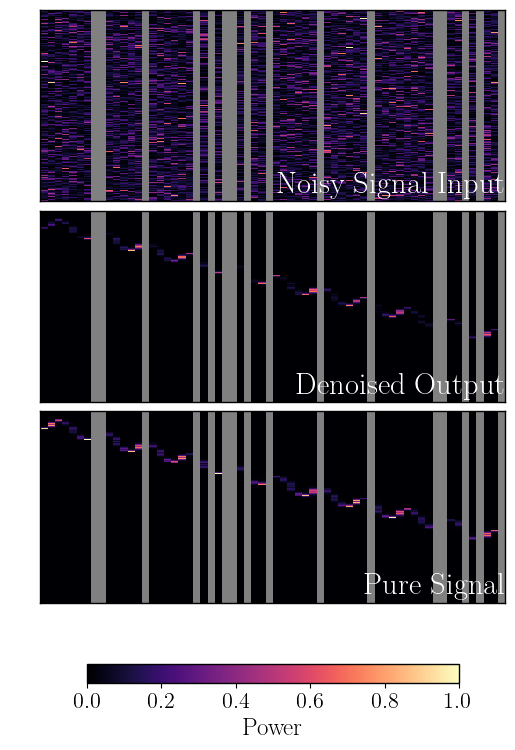

In [10]:
# Example usage
idx = 8
size = (512, 64)  # From your original code
Tsft = 14400  # From your original code
timestamps = np.arange(0, size[1]) * Tsft  # Uniform timestamps
frequency = np.arange(200)  # Adjusted to match [96:256-32] slice
title = 'Spectrograms at 500 Hz'
subtitles = ['Noisy Signal Input', 'Denoised Output', 'Pure Signal']
fourier_data_list = [
    data[idx][-300:-100, :, :2],  # Shape: (160, 64, 2) selecting H1 real and imag
    predictions[idx].transpose(1, 2, 0)[-300:-100, :, :2],  # Adjusted to match data shape
    normalize(targets)[idx][-300:-100, :, :2]
]
fig, ax = plot_spectrograms(title, timestamps, frequency, fourier_data_list, subtitles)
fig.savefig('../result/plots/500Hz_D20_spectrogram_gaps.pdf', dpi=300, bbox_inches='tight')